# Task Test Notebook

Generate small Brady-dataset examples for each memory task and subtype. This notebook does not run any models; it only displays generated study/test inputs and the expected targets/metadata.

In [75]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
from IPython.display import JSON, Markdown, display
from PIL import Image

random.seed(7)

ROOT = Path.cwd()
print(f"Notebook root: {ROOT}")

Notebook root: /Users/chrisiyer/_Current/lab/code/vision-memory


In [76]:
def is_image(value):
    return isinstance(value, Image.Image)


def scrub(value):
    """Convert task objects into JSON-displayable previews without dumping image bytes."""
    if is_image(value):
        return f"<PIL.Image mode={value.mode} size={value.size}>"
    if isinstance(value, dict):
        return {k: scrub(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [scrub(v) for v in value]
    return value


def image_caption(item, fallback):
    if isinstance(item, dict):
        bits = []
        if item.get("pair_type"):
            bits.append(str(item["pair_type"]))
        if item.get("word"):
            bits.append(f"word={item['word']}")
        if item.get("type"):
            bits.append(str(item["type"]))
        if item.get("options"):
            bits.append("options=" + " / ".join(str(x) for x in item["options"]))
        return " | ".join(bits) or fallback
    if isinstance(item, tuple) and len(item) == 2 and is_image(item[0]):
        return f"word={item[1]}"
    return fallback


def collect_images(item):
    """Return a list of (image, label) pairs from any task study/test record."""
    if is_image(item):
        return [(item, "image")]
    if isinstance(item, tuple) and len(item) == 2 and is_image(item[0]):
        return [(item[0], f"word: {item[1]}")]
    if isinstance(item, dict):
        images = []
        if is_image(item.get("cue_image")):
            images.append((item["cue_image"], "cue"))
        if is_image(item.get("image")):
            images.append((item["image"], "probe"))
        for idx, img in enumerate(item.get("images", []) or [], start=1):
            if is_image(img):
                images.append((img, f"option {idx}"))
        if is_image(item.get("color_wheel")):
            images.append((item["color_wheel"], "color wheel"))
        return images
    return []


def show_image_row(items, title=None, max_items=8, thumb=2.2):
    entries = []
    for i, item in enumerate(items[:max_items], start=1):
        caption = image_caption(item, f"{i}")
        imgs = collect_images(item)
        if len(imgs) == 1:
            entries.append((imgs[0][0], caption if caption != str(i) else f"{i}: {imgs[0][1]}"))
        else:
            for img, label in imgs:
                entries.append((img, f"{i}: {label}" if caption == str(i) else f"{i}: {caption} / {label}"))

    if title:
        display(Markdown(f"**{title}**"))
    if not entries:
        display(Markdown("No images to display."))
        return

    fig, axes = plt.subplots(1, len(entries), figsize=(thumb * len(entries), thumb))
    if len(entries) == 1:
        axes = [axes]
    for ax, (img, label) in zip(axes, entries):
        ax.imshow(img)
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def unique_prompts(result, test_key="test_phase"):
    if isinstance(result, list):
        prompts = [trial.get("prompt") for trial in result if isinstance(trial, dict) and trial.get("prompt")]
    else:
        prompts = [result.get("study_prompt")]
        prompts.extend(
            trial.get("prompt")
            for trial in result.get(test_key, [])
            if isinstance(trial, dict) and trial.get("prompt")
        )
    seen = []
    for prompt in prompts:
        if prompt and prompt not in seen:
            seen.append(prompt)
    return seen


def show_model_prompts(result, test_key="test_phase"):
    prompts = unique_prompts(result, test_key=test_key)
    if not prompts:
        return
    lines = ["**Model prompts**"]
    for i, prompt in enumerate(prompts, start=1):
        lines.append(f"{i}. `{prompt}`")
    display(Markdown("\n".join(lines)))


def format_target_value(value):
    if isinstance(value, float):
        return f"{value:.2f}"
    return str(value)


def target_rows(trials):
    rows = []
    for i, trial in enumerate(trials, start=1):
        if not isinstance(trial, dict):
            continue
        target = trial.get("target", "")
        correct = ""
        prompt = trial.get("prompt", "")
        if "already appeared" in prompt and target in {0, 1}:
            correct = "yes" if target == 1 else "no"
        elif "position in the sequence" in prompt:
            correct = str(target)
        elif isinstance(target, int) and (trial.get("options") or trial.get("images")):
            correct = str(target)
        elif trial.get("type") and isinstance(target, str):
            correct = target
        elif "target_angle_degrees" in trial.get("metadata", {}):
            correct = f"{trial['metadata']['target_angle_degrees']:.2f} degrees"
        elif isinstance(target, str):
            correct = target

        detail = []
        if trial.get("type"):
            detail.append(f"type={trial['type']}")
        metadata = trial.get("metadata", {})
        for key in ["delay", "serial_position", "serial_lag", "distance", "bin"]:
            if metadata.get(key) is not None:
                detail.append(f"{key}={metadata[key]}")
        if trial.get("options"):
            detail.append("options=" + " / ".join(str(x) for x in trial["options"]))

        rows.append({
            "trial": i,
            "target": format_target_value(target),
            "correct_response": correct,
            "details": "; ".join(detail),
        })
    return rows


def show_targets(trials, title="Target outputs"):
    rows = target_rows(trials)
    if rows:
        table = [f"**{title}**", "", "| trial | target | correct response | details |", "|---:|---|---|---|"]
        for row in rows:
            table.append(
                f"| {row['trial']} | {row['target']} | {row['correct_response']} | {row['details']} |"
            )
        display(Markdown("\n".join(table)))


def show_task_result(name, result, study_key="study_sequence", test_key="test_phase", n_study=6, n_test=3):
    display(Markdown(f"## {name}"))
    if isinstance(result, list):
        display(Markdown(f"Generated sequence trials: `{len(result)}`"))
        show_model_prompts(result, test_key=test_key)
        show_image_row(result, "Sequence preview", max_items=n_study)
        show_targets(result[:n_test])
        display(JSON(scrub(result[:n_test])))
        return

    display(Markdown(f"Study prompt: {result.get('study_prompt', '(none)')}"))
    display(Markdown(f"Study items: `{len(result.get(study_key, []))}` | Test trials: `{len(result.get(test_key, []))}`"))
    show_model_prompts(result, test_key=test_key)
    if result.get("color_wheel") is not None:
        show_image_row([result["color_wheel"]], "Color wheel", max_items=1, thumb=4)
    show_image_row(result.get(study_key, []), "Study preview", max_items=n_study)
    show_image_row(result.get(test_key, []), "Test preview", max_items=n_test)
    show_targets(result.get(test_key, [])[:n_test])
    display(JSON(scrub(result.get(test_key, [])[:n_test])))

In [77]:
import importlib

import tasks.recognition as recognition
import tasks.serial_order_memory as serial_order_memory
import tasks.paired_associate_memory as paired_associate_memory
import tasks.associative_inference as associative_inference
import tasks.mnemonic_similarity as mnemonic_similarity

recognition = importlib.reload(recognition)
serial_order_memory = importlib.reload(serial_order_memory)
paired_associate_memory = importlib.reload(paired_associate_memory)
associative_inference = importlib.reload(associative_inference)
mnemonic_similarity = importlib.reload(mnemonic_similarity)

AFCRecognitionTask = recognition.AFCRecognitionTask
ContinuousRecognitionTask = recognition.ContinuousRecognitionTask
AFCSerialOrderMemoryTask = serial_order_memory.AFCSerialOrderMemoryTask
SerialOrderMemoryTask = serial_order_memory.SerialOrderMemoryTask
PairedAssociateMemoryTask = paired_associate_memory.PairedAssociateMemoryTask
AssociativeInferenceTask = associative_inference.AssociativeInferenceTask
MnemonicSimilarityTask = mnemonic_similarity.MnemonicSimilarityTask

try:
    import tasks.color_memory as color_memory
    color_memory = importlib.reload(color_memory)
    ColorMemoryTask = color_memory.ColorMemoryTask
    COLOR_IMPORT_ERROR = None
except Exception as exc:
    ColorMemoryTask = None
    COLOR_IMPORT_ERROR = exc

print("Task imports complete")
if COLOR_IMPORT_ERROR:
    print(f"ColorMemoryTask unavailable until its dependency is installed: {COLOR_IMPORT_ERROR!r}")

Task imports complete


## Recognition Tasks

## Continuous recognition

Generated sequence trials: `16`

**Model prompts**
1. `Has this image already appeared in the sequence? (yes/no)`

**Sequence preview**

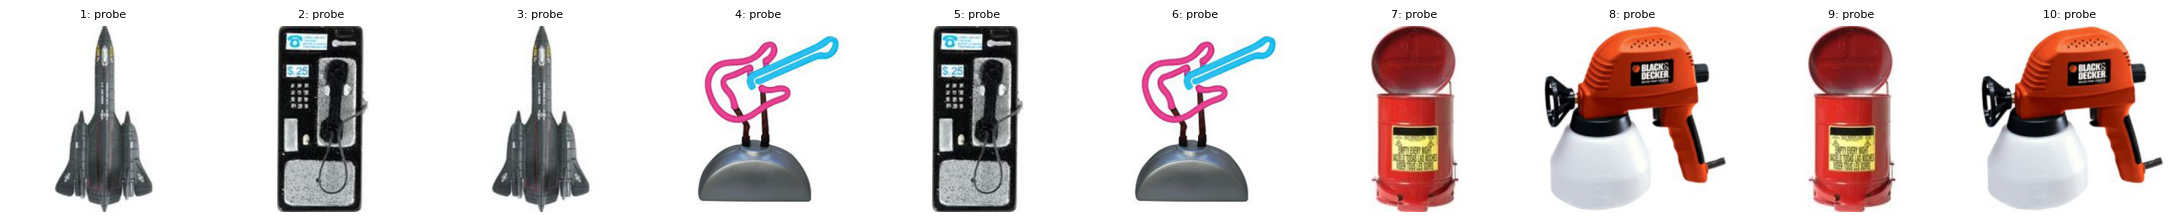

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 0 | no |  |
| 2 | 0 | no |  |
| 3 | 1 | yes | delay=1 |
| 4 | 0 | no |  |
| 5 | 1 | yes | delay=2 |
| 6 | 1 | yes | delay=1 |

<IPython.core.display.JSON object>

In [78]:
continuous = ContinuousRecognitionTask(dataset_name="Brady2008", n_images=8, min_delay=1, max_delay=4, p_old=0.5)
show_task_result("Continuous recognition", continuous.get_trials(), n_study=10, n_test=6)

## 2-AFC recognition / foil_type=novel

Study prompt: Here is a sequence of images to remember.

Study items: `6` | Test trials: `6`

**Model prompts**
1. `Here is a sequence of images to remember.`
2. `Which of these two images (1 or 2) was in the study sequence?`

**Study preview**

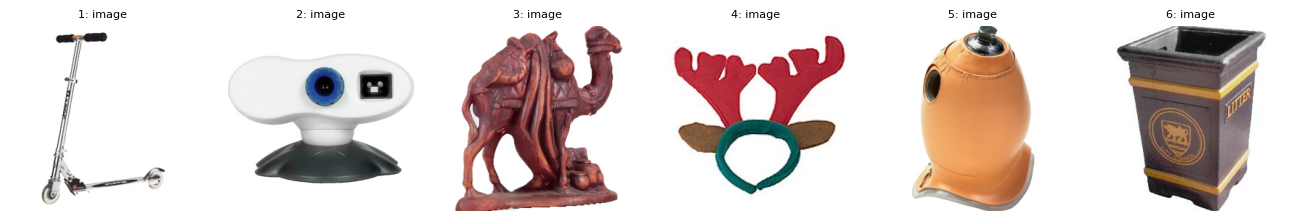

**Test preview**

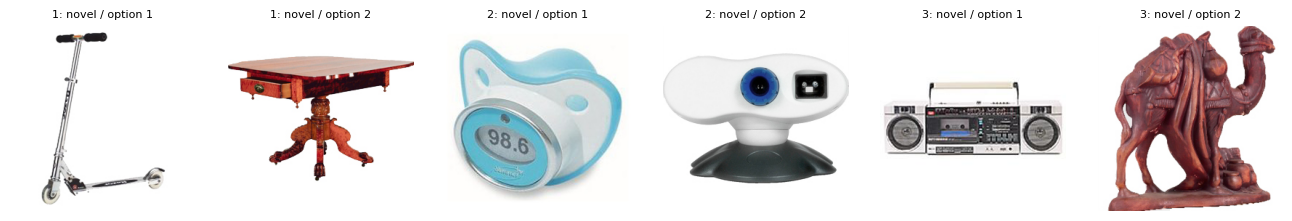

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 1 | 1 | type=novel |
| 2 | 2 | 2 | type=novel |
| 3 | 2 | 2 | type=novel |

<IPython.core.display.JSON object>

## 2-AFC recognition / foil_type=exemplar

Study prompt: Here is a sequence of images to remember.

Study items: `6` | Test trials: `6`

**Model prompts**
1. `Here is a sequence of images to remember.`
2. `Which of these two images (1 or 2) was in the study sequence?`

**Study preview**

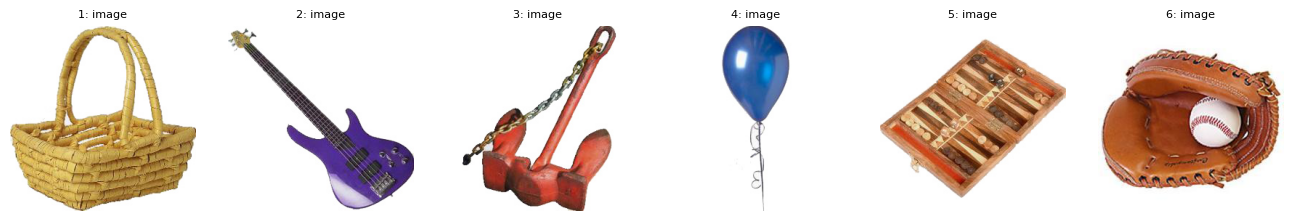

**Test preview**

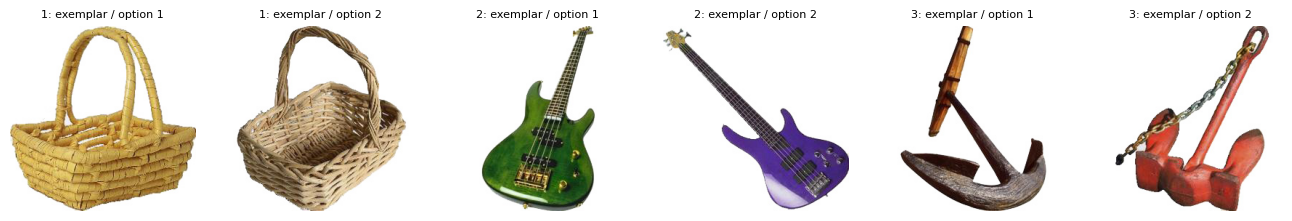

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 1 | 1 | type=exemplar |
| 2 | 2 | 2 | type=exemplar |
| 3 | 2 | 2 | type=exemplar |

<IPython.core.display.JSON object>

## 2-AFC recognition / foil_type=state

Study prompt: Here is a sequence of images to remember.

Study items: `6` | Test trials: `6`

**Model prompts**
1. `Here is a sequence of images to remember.`
2. `Which of these two images (1 or 2) was in the study sequence?`

**Study preview**

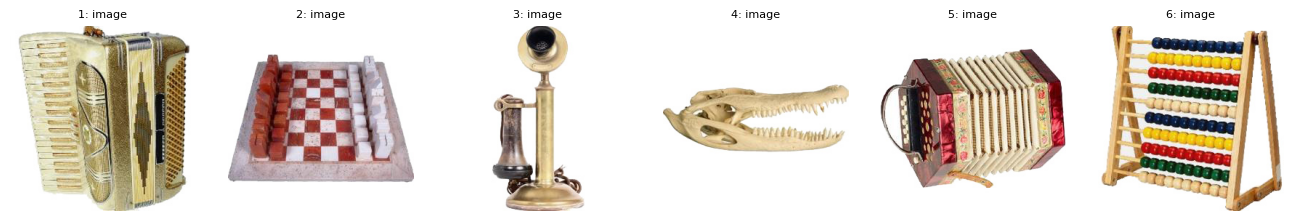

**Test preview**

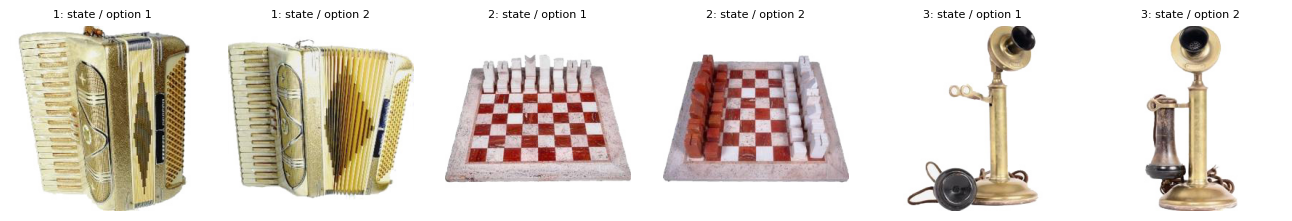

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 1 | 1 | type=state |
| 2 | 2 | 2 | type=state |
| 3 | 2 | 2 | type=state |

<IPython.core.display.JSON object>

## 2-AFC recognition / foil_type=all

Study prompt: Here is a sequence of images to remember.

Study items: `6` | Test trials: `6`

**Model prompts**
1. `Here is a sequence of images to remember.`
2. `Which of these two images (1 or 2) was in the study sequence?`

**Study preview**

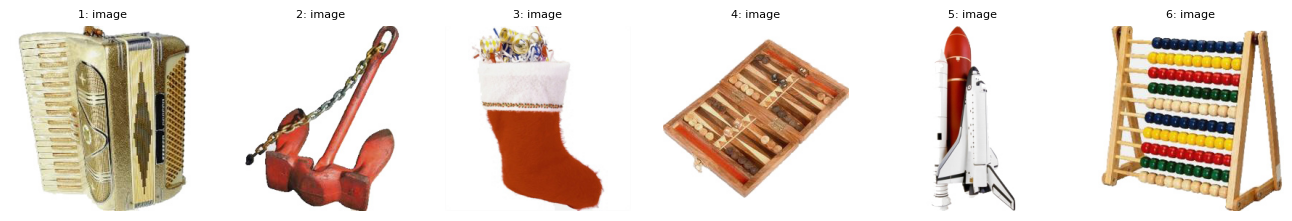

**Test preview**

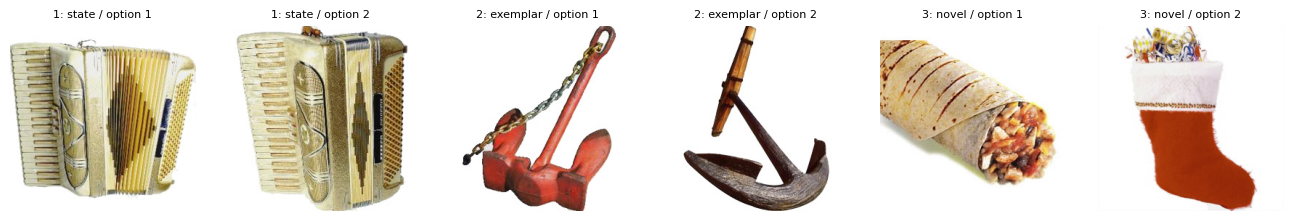

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 2 | 2 | type=state |
| 2 | 1 | 1 | type=exemplar |
| 3 | 2 | 2 | type=novel |

<IPython.core.display.JSON object>

In [79]:
for foil_type in ["novel", "exemplar", "state", "all"]:
    task = AFCRecognitionTask(dataset_name="Brady2008", n_images=6, foil_type=foil_type)
    show_task_result(f"2-AFC recognition / foil_type={foil_type}", task.get_trials(), n_study=6, n_test=3)

## Serial Order Tasks

## Serial order / free position report

Study prompt: Here is a sequence of 6 images to remember in order.

Study items: `6` | Test trials: `6`

**Model prompts**
1. `Here is a sequence of 6 images to remember in order.`
2. `What position in the sequence did this image appear (1-6)?`

**Study preview**

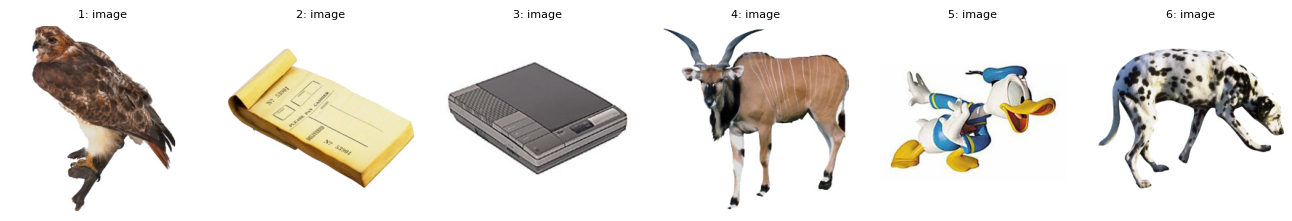

**Test preview**

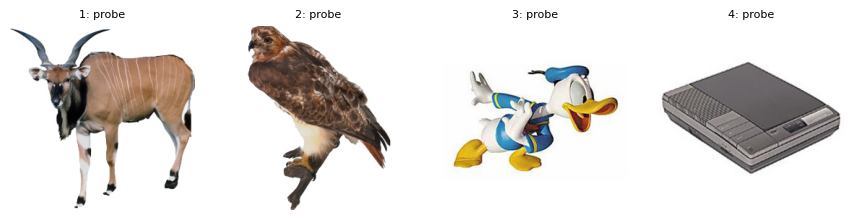

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 4 | 4 | serial_position=4 |
| 2 | 1 | 1 | serial_position=1 |
| 3 | 5 | 5 | serial_position=5 |
| 4 | 3 | 3 | serial_position=3 |

<IPython.core.display.JSON object>

## Serial order / 2-AFC

Study prompt: Here is a sequence of 6 images to remember in order.

Study items: `6` | Test trials: `5`

**Model prompts**
1. `Here is a sequence of 6 images to remember in order.`
2. `Which of these two images (1 or 2) appeared first in the study sequence?`

**Study preview**

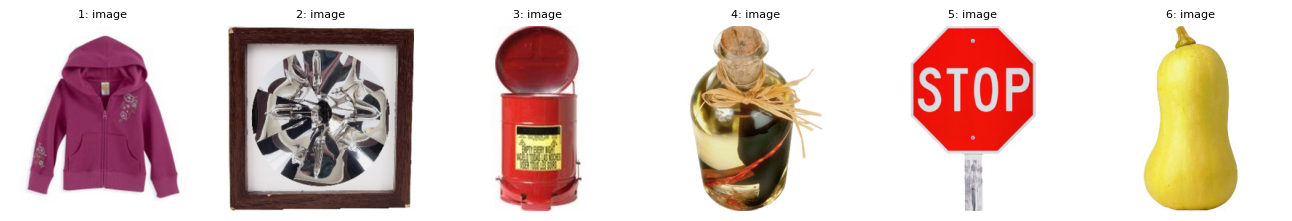

**Test preview**

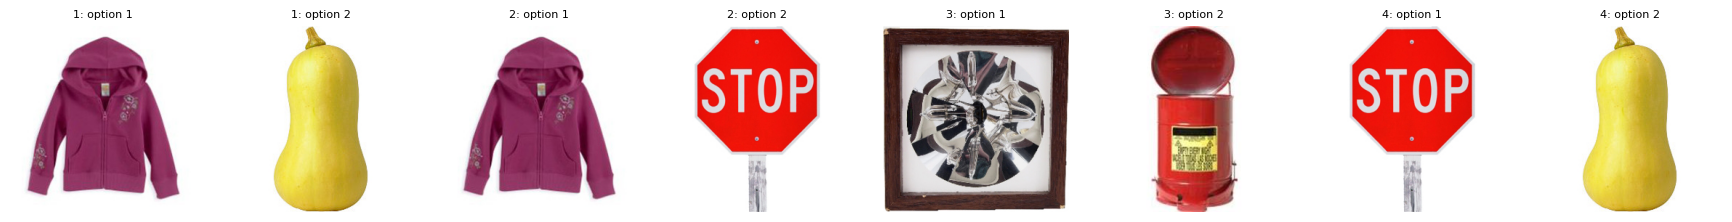

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 1 | 1 | serial_lag=5; distance=4 |
| 2 | 1 | 1 | serial_lag=4; distance=3 |
| 3 | 1 | 1 | serial_lag=1; distance=0 |
| 4 | 1 | 1 | serial_lag=1; distance=0 |

<IPython.core.display.JSON object>

In [80]:
serial_free = SerialOrderMemoryTask(dataset_name="Brady2008", n_images=6)
show_task_result("Serial order / free position report", serial_free.get_trials(), n_study=6, n_test=4)

serial_afc = AFCSerialOrderMemoryTask(dataset_name="Brady2008", n_images=6, n_tests=5)
show_task_result("Serial order / 2-AFC", serial_afc.get_trials(), n_study=6, n_test=4)

## Paired Associate Memory

## Paired associate memory / pair_type=word

Study prompt: Remember the word paired with each image.

Study items: `5` | Test trials: `5`

**Model prompts**
1. `Remember the word paired with each image.`
2. `What was the word paired with this image?`

**Study preview**

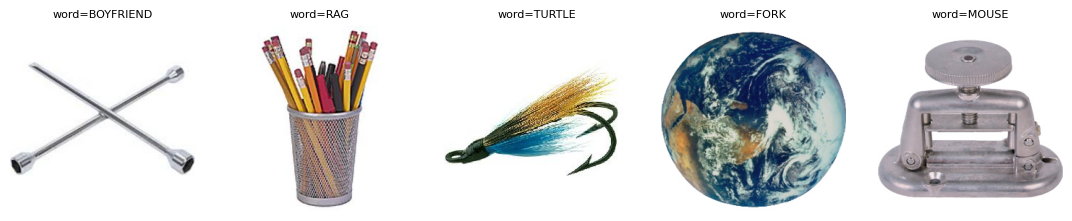

**Test preview**

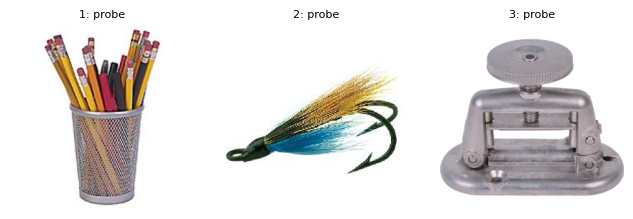

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | RAG | RAG |  |
| 2 | TURTLE | TURTLE |  |
| 3 | MOUSE | MOUSE |  |

<IPython.core.display.JSON object>

## Paired associate memory / pair_type=image

Study prompt: Remember which images were paired together.

Study items: `5` | Test trials: `5`

**Model prompts**
1. `Remember which images were paired together.`
2. `Which of these two images (1 or 2) was paired with the cue image?`

**Study preview**

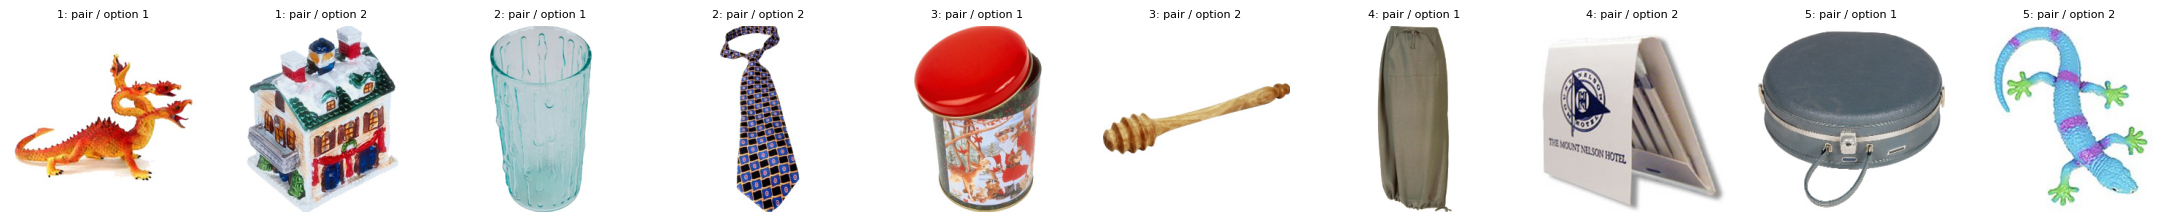

**Test preview**

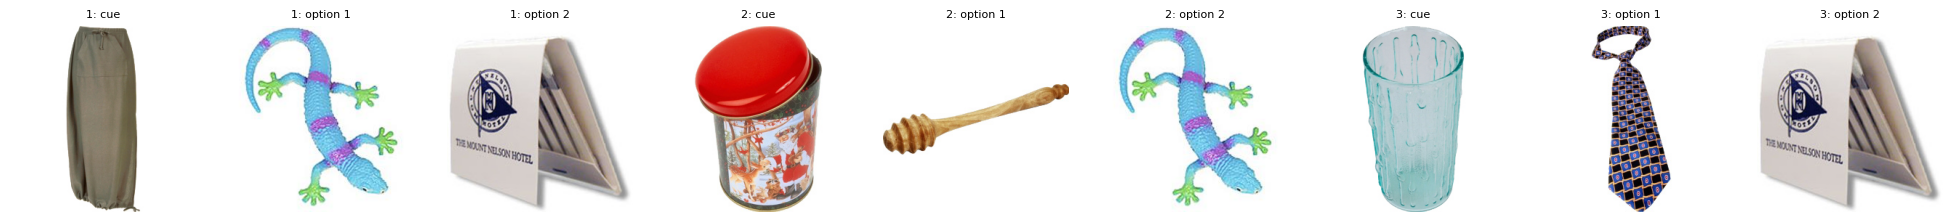

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 2 | 2 |  |
| 2 | 1 | 1 |  |
| 3 | 1 | 1 |  |

<IPython.core.display.JSON object>

In [81]:
for pair_type in ["word", "image"]:
    task = PairedAssociateMemoryTask(dataset_name="Brady2008", n_images=5, pair_type=pair_type)
    show_task_result(f"Paired associate memory / pair_type={pair_type}", task.get_trials(), n_study=5, n_test=3)

## Associative Inference

## Associative inference / pair_type=word

Study prompt: Remember these pairs, and pay attention to hidden connections between them. First you will see a sequence of image-image or image-word pairs. Then you will be tested on your memory for connections between items.

Study items: `6` | Test trials: `3`

**Model prompts**
1. `Remember these pairs, and pay attention to hidden connections between them. First you will see a sequence of image-image or image-word pairs. Then you will be tested on your memory for connections between items.`
2. `Which of these two words (1 or 2) is indirectly associated with the cue image?`

**Study preview**

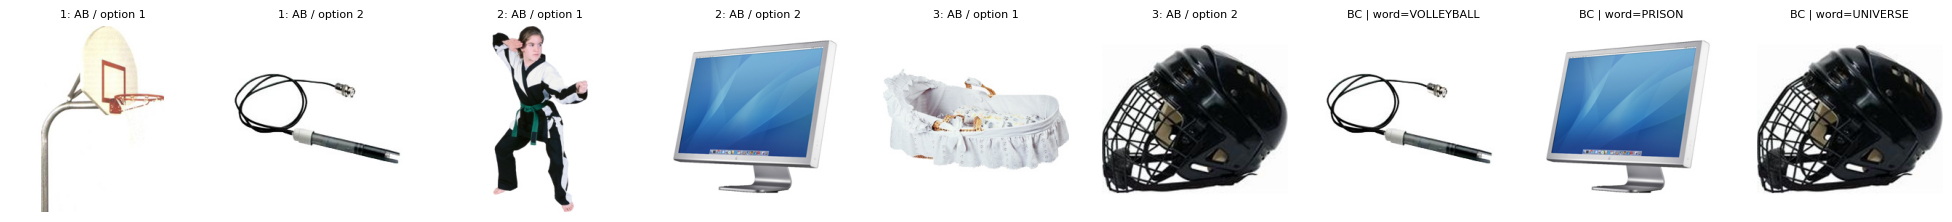

**Test preview**

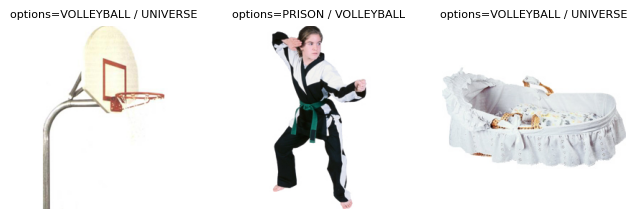

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 1 | 1 | options=VOLLEYBALL / UNIVERSE |
| 2 | 1 | 1 | options=PRISON / VOLLEYBALL |
| 3 | 2 | 2 | options=VOLLEYBALL / UNIVERSE |

<IPython.core.display.JSON object>

## Associative inference / pair_type=image

Study prompt: Remember these pairs, and pay attention to hidden connections between them. First you will see a sequence of image-image pairs. Then you will be tested on your memory for connections between items.

Study items: `6` | Test trials: `3`

**Model prompts**
1. `Remember these pairs, and pay attention to hidden connections between them. First you will see a sequence of image-image pairs. Then you will be tested on your memory for connections between items.`
2. `Which of these two images (1 or 2) is indirectly associated with the cue image?`

**Study preview**

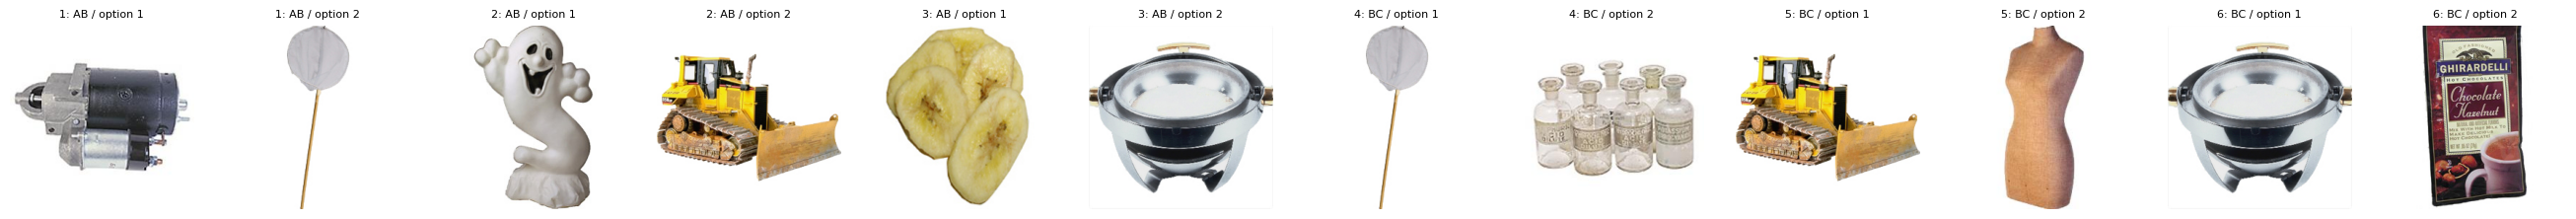

**Test preview**

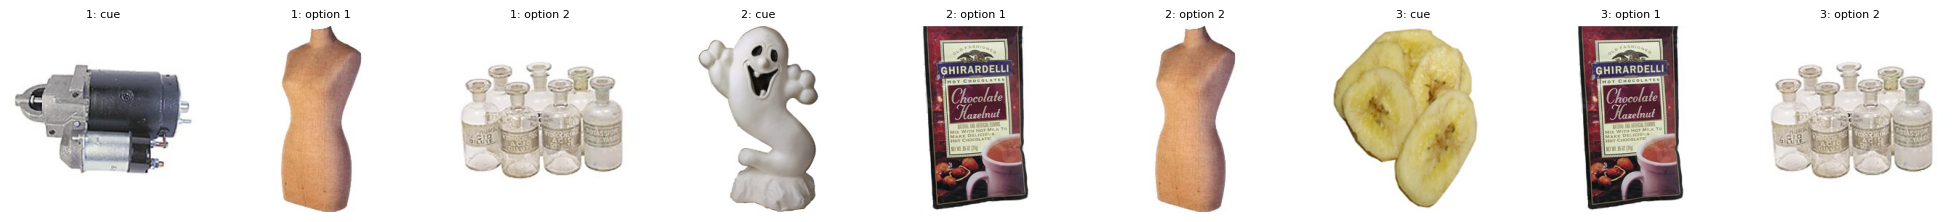

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 2 | 2 |  |
| 2 | 2 | 2 |  |
| 3 | 1 | 1 |  |

<IPython.core.display.JSON object>

In [82]:
for pair_type in ["word", "image"]:
    task = AssociativeInferenceTask(dataset_name="Brady2008", n_trials=6, pair_type=pair_type)
    show_task_result(f"Associative inference / pair_type={pair_type}", task.get_trials(), n_study=6, n_test=3)

## Color Memory

## Color memory / mode=continuous_color_report

Study prompt: Remember the colors of these items.

Study items: `5` | Test trials: `5`

**Model prompts**
1. `Remember the colors of these items.`
2. `What was the color of this item in the study sequence? Report the hue angle in degrees on the color wheel. 0/360 degrees is the rightmost point, 90 is the top, 180 is the left, and 270 is the bottom. Use any number from 0 up to 360.`

**Color wheel**

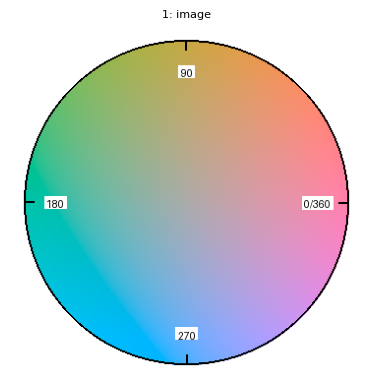

**Study preview**

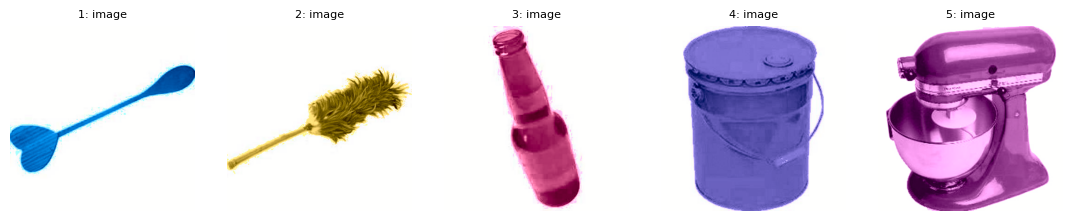

**Test preview**

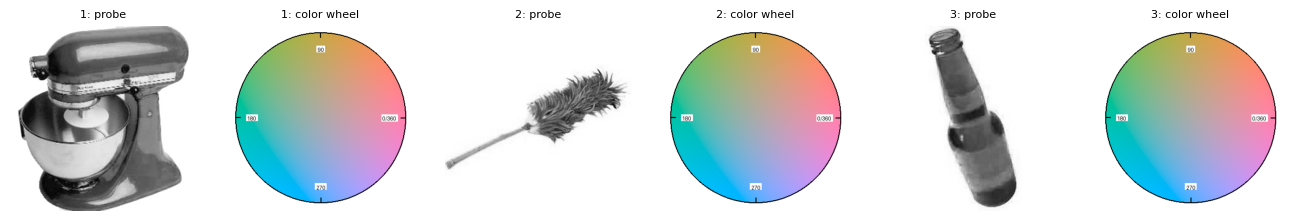

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | 329.59 | 329.59 degrees |  |
| 2 | 89.03 | 89.03 degrees |  |
| 3 | 357.74 | 357.74 degrees |  |

<IPython.core.display.JSON object>

## Color memory / mode=named

Study prompt: Remember the colors of these items.

Study items: `5` | Test trials: `5`

**Model prompts**
1. `Remember the colors of these items.`
2. `What color was this item in the study sequence? Choose one: red, orange, yellow, green, blue, purple.`

**Study preview**

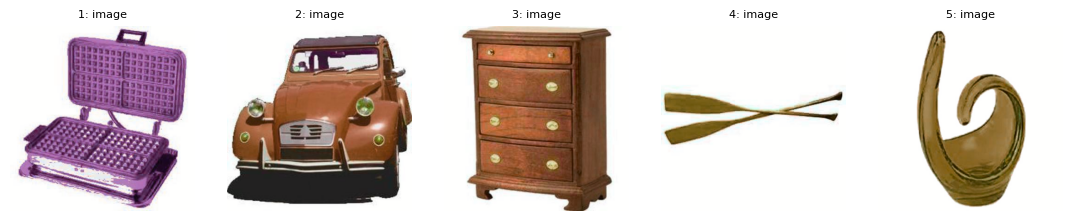

**Test preview**

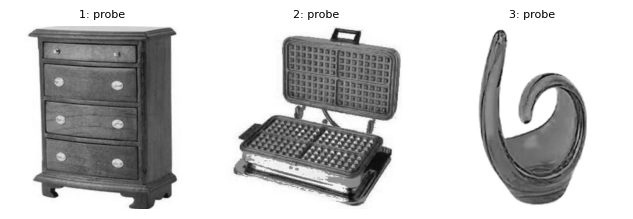

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | orange | orange |  |
| 2 | purple | purple |  |
| 3 | yellow | yellow |  |

<IPython.core.display.JSON object>

In [83]:
if COLOR_IMPORT_ERROR:
    display(Markdown(
        "Color-memory examples are skipped because `tasks.color_memory` could not import. "
        "Install dependencies from `requirements.txt` so `opencv-python` / `cv2` is available, then rerun this cell."
    ))
else:
    for mode in ["continuous_color_report", "named"]:
        task = ColorMemoryTask(n_images=5, mode=mode)
        show_task_result(f"Color memory / mode={mode}", task.get_trials(), n_study=5, n_test=3)

## Mnemonic Similarity Task

`MnemonicSimilarityTask` uses the MST stimuli in `memory_datasets/MST/`. It is included here now that the set folders and bin files are present.

## Mnemonic similarity task

Study prompt: Study these 10 images carefully. You will later be tested on your memory for them.

Study items: `10` | Test trials: `30`

**Model prompts**
1. `Study these 10 images carefully. You will later be tested on your memory for them.`
2. `Is this image: (1) old — exactly as you saw it before, (2) similar — like something you saw but not identical, or (3) new — not seen before? Respond with one word: old, similar, or new.`

**Study preview**

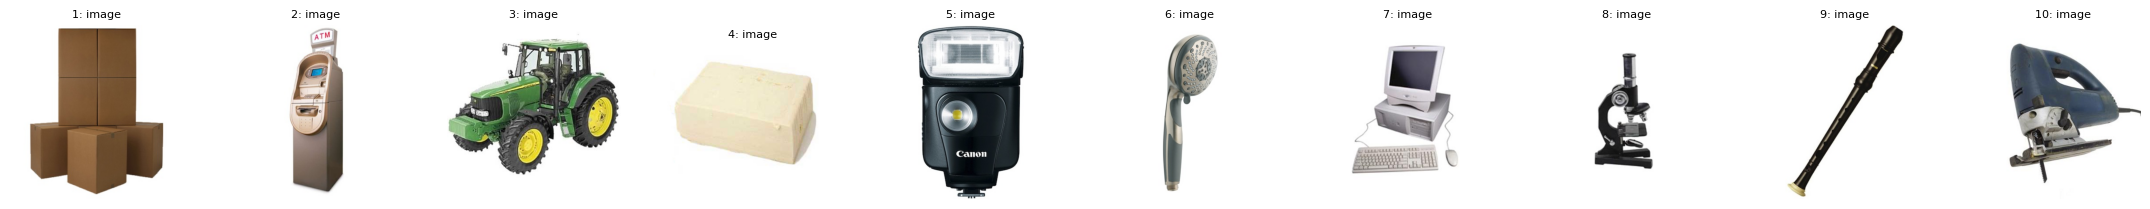

**Test preview**

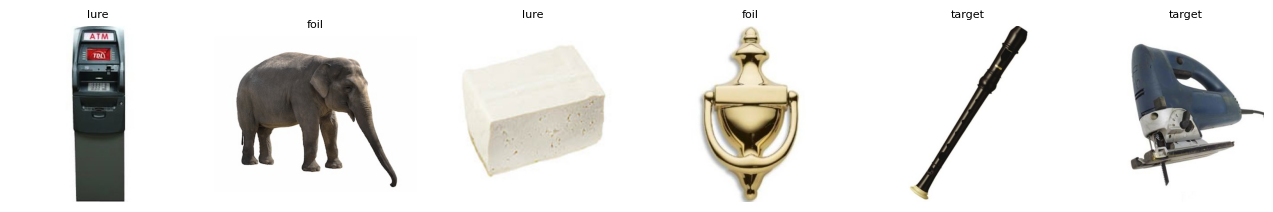

**Target outputs**

| trial | target | correct response | details |
|---:|---|---|---|
| 1 | similar | similar | type=lure; bin=4 |
| 2 | new | new | type=foil |
| 3 | similar | similar | type=lure; bin=1 |
| 4 | new | new | type=foil |
| 5 | old | old | type=target |
| 6 | old | old | type=target |

<IPython.core.display.JSON object>

In [ ]:
mst_root = ROOT / "memory_datasets" / "MST"
task = MnemonicSimilarityTask(n_study=10, root=str(mst_root))
show_task_result("Mnemonic similarity task", task.get_trials(), n_study=10, n_test=6)
